# Haselburg Marteloscope Stem Volume Analysis

**Project:** Calculation of tree stem volume using Zianis et al. (2005) equations.

**Aurthor:** Hassan Akhter

**Date:** February 10, 2026

--

## Introduction

This analysis calculates the stem volume for trees in the Haselburg Marteloscope using species-specific allomertic equations from Zianis et al. (2005).

**Used Method:**

- Regression allomertic equations
- Species-specific parameters (a, b, c, d, e, f coefficients)
- Different formulas for different species

**The analysis includes:**
1. Volume calculation of all trees
2. Validation against reference volumes
3. Statistical analysis by species
4. Visualizations

## Step 1: Import Libraries

First, we import the pzthon libraries we need for the data analysis and visualization

In [1]:
#Import libraries for data analysis
import pandas as pd   #for working with tables/spreadsheets
import numpy as np    #for calculations
import matplotlib.pyplot as plt    #for creating graphs
import seaborn as sns
print("Libraries installed Successfully!")

Libraries installed Successfully!


## Step 2: Load Data from Excel File

We load the Haselburg Marteloscope Data which contains:
- Tree measurements (diameter, height)
- Species information
- Reference volumes for validation

In [2]:
#Specify the path to your Excel file
data_file = "M_scope_Haselberg_final.xlsx"

#Load the tree data from the Excel file
tree_data = pd.read_excel(data_file, sheet_name = 'M-scope_Data_Sheet')

## Preview the Data

Let's look at the first few rows to see what data we have

In [3]:
tree_data.head(10) 
# head() by default shows first five rows

,Tree No,TrSpec,d 1.3 [cm],h [m],CBH [m],QMP,Status,X [°],Y [m],BA [m²],...,D/IT [Euro; national currency],Fuel wood [Euro; national currency],Econ. Value [Euro],No. TReMs,x,y,x4load,y4load,Unnamed: 32,Unnamed: 33
0,1,Fagus sylvatica,50.6,31.2,-4.9,1,1,432507.513,5842264.609,0.201090,...,103.75,44.20,NaN,0,66.091736,95.534032,66.09,95.53,NaN,NaN
1,2,Fagus sylvatica,17.9,22.1,-4.9,1,1,432508.802,5842277.426,0.025165,...,0.00,14.67,NaN,0,71.996367,91.816513,72.00,91.82,NaN,NaN
2,3,Fagus sylvatica,37.7,29.1,-4.9,1,1,432507.007,5842285.790,0.111628,...,0.00,27.05,NaN,1,72.544160,95.766441,72.54,95.77,NaN,NaN
3,4,Fagus sylvatica,37.4,30.5,-4.9,1,1,432505.541,5842284.058,0.109858,...,0.00,29.75,NaN,1,67.341368,97.556594,67.34,97.56,NaN,NaN
4,5,Fagus sylvatica,30.0,27.7,-4.9,1,1,432511.420,5842273.337,0.070686,...,0.00,5.84,NaN,3,75.458616,88.412593,75.46,88.41,NaN,NaN
5,6,Fagus sylvatica,57.9,29.5,-4.9,1,1,432516.197,5842272.809,0.263298,...,0.00,163.62,NaN,4,78.838114,91.442569,78.84,91.44,NaN,NaN
6,7,Fagus sylvatica,17.8,18.3,-4.9,1,1,432516.061,5842269.953,0.024885,...,7.43,0.00,NaN,0,80.736268,86.146156,80.74,86.15,NaN,NaN
7,8,Fagus sylvatica,32.5,30.0,-4.9,1,1,432525.443,5842272.363,0.082958,...,0.00,17.22,NaN,2,89.346766,90.583424,89.35,90.58,NaN,NaN
8,9,Fagus sylvatica,52.0,30.7,-4.9,1,1,432526.452,5842270.848,0.212372,...,0.00,42.00,NaN,3,90.667587,89.330932,90.67,89.33,NaN,NaN
9,10,Fagus sylvatica,25.3,27.5,-4.9,1,1,432526.719,5842270.050,0.050273,...,0.00,30.30,NaN,1,91.105465,88.612352,91.11,88.61,NaN,NaN


In [4]:
#Descriptive Statistics of the data
tree_data.describe().round()

,Tree No,d 1.3 [cm],h [m],CBH [m],QMP,Status,X [°],Y [m],BA [m²],V [m³],...,D/IT [Euro; national currency],Fuel wood [Euro; national currency],Econ. Value [Euro],No. TReMs,x,y,x4load,y4load,Unnamed: 32,Unnamed: 33
count,312.0,312.0,312.0,312.0,312.0,312.0,312.0,312.0,312.0,312.0,...,312.0,312.0,0.0,312.0,312.0,312.0,312.0,312.0,0.0,1.0
mean,156.0,35.0,27.0,-5.0,3.0,1.0,432475.0,5842244.0,0.0,2.0,...,9.0,26.0,NaN,2.0,46.0,52.0,46.0,52.0,NaN,7.0
std,90.0,14.0,6.0,0.0,1.0,0.0,29.0,30.0,0.0,1.0,...,24.0,29.0,NaN,2.0,30.0,29.0,30.0,29.0,NaN,NaN
min,1.0,8.0,4.0,-5.0,1.0,0.0,432422.0,5842186.0,0.0,0.0,...,0.0,0.0,NaN,0.0,1.0,0.0,1.0,0.0,NaN,7.0
25%,79.0,24.0,26.0,-5.0,2.0,1.0,432449.0,5842219.0,0.0,1.0,...,0.0,3.0,NaN,0.0,20.0,28.0,20.0,28.0,NaN,7.0
50%,156.0,34.0,28.0,-5.0,3.0,1.0,432470.0,5842244.0,0.0,1.0,...,0.0,19.0,NaN,1.0,42.0,55.0,42.0,55.0,NaN,7.0
75%,234.0,45.0,31.0,-5.0,4.0,1.0,432502.0,5842270.0,0.0,2.0,...,0.0,36.0,NaN,3.0,74.0,78.0,74.0,78.0,NaN,7.0
max,312.0,78.0,38.0,-5.0,4.0,1.0,432532.0,5842299.0,0.0,8.0,...,161.0,164.0,NaN,16.0,99.0,99.0,99.0,99.0,NaN,7.0


In [5]:
#type of data we are dealing with
tree_data.dtypes

Tree No                                  int64
TrSpec                                  object
d 1.3 [cm]                             float64
h [m]                                  float64
CBH [m]                                float64
QMP                                      int64
Status                                   int64
X [°]                                  float64
Y [m]                                  float64
BA [m²]                                float64
V [m³]                                 float64
A [m³]                                 float64
B [m³]                                 float64
C [m³]                                 float64
D/IT [m³]                              float64
Fuel wood [m³]                         float64
A [m]                                  float64
B [m]                                  float64
C [m]                                  float64
D/IT [m]                               float64
Fuel wood [m]                          float64
A [Euro; nati

In [6]:
#species
Species =tree_data["TrSpec"].unique()
Species

array(['Fagus sylvatica', 'Betula pendula', 'Acer pseudoplatanus',
       'Carpinus betulus', 'Pinus sylvestris', 'Quercus robur',
       'Larix decidua', 'Picea Abies'], dtype=object)

In [7]:
#Lets look at which species is dominant
tree_data["TrSpec"].value_counts()

TrSpec
Fagus sylvatica        234
Pinus sylvestris        31
Betula pendula          28
Carpinus betulus         8
Picea Abies              6
Acer pseudoplatanus      3
Quercus robur            1
Larix decidua            1
Name: count, dtype: int64

In [8]:
#Mean DBH (diameter at 1.3m height) in cm for each species
for S in Species:
    print("_"*15)
    print(S)
    print(tree_data[tree_data["TrSpec"]==S]["d 1.3 [cm]"].mean())

_______________
Fagus sylvatica
32.22179487179487
_______________
Betula pendula
42.33571428571429
_______________
Acer pseudoplatanus
49.03333333333333
_______________
Carpinus betulus
19.900000000000002
_______________
Pinus sylvestris
47.825806451612905
_______________
Quercus robur
28.5
_______________
Larix decidua
78.3
_______________
Picea Abies
36.4


In [9]:
tree_data.groupby("TrSpec")["d 1.3 [cm]"].agg(['mean', 'min', 'max', 'count'])

,mean,min,max,count
TrSpec,,,,
Acer pseudoplatanus,49.033333,43.4,54.9,3
Betula pendula,42.335714,25.8,61.9,28
Carpinus betulus,19.900000,14.1,27.8,8
Fagus sylvatica,32.221795,8.0,70.5,234
Larix decidua,78.300000,78.3,78.3,1
Picea Abies,36.400000,18.4,68.8,6
Pinus sylvestris,47.825806,32.3,67.7,31
Quercus robur,28.500000,28.5,28.5,1


In [10]:
#Mean DBH of each species
tree_data.groupby("TrSpec")["d 1.3 [cm]"].mean().round(1)

TrSpec
Acer pseudoplatanus    49.0
Betula pendula         42.3
Carpinus betulus       19.9
Fagus sylvatica        32.2
Larix decidua          78.3
Picea Abies            36.4
Pinus sylvestris       47.8
Quercus robur          28.5
Name: d 1.3 [cm], dtype: float64

In [11]:
#Mean height of each species
tree_data.groupby("TrSpec")["h [m]"].mean().round(1)

TrSpec
Acer pseudoplatanus    29.9
Betula pendula         26.2
Carpinus betulus       22.3
Fagus sylvatica        26.8
Larix decidua          36.7
Picea Abies            26.6
Pinus sylvestris       32.2
Quercus robur          26.3
Name: h [m], dtype: float64

## Step 3: Define the Volume Calculation Function

### The Zianis Allomertic Equation
According to Zianis et al. (2005), stem volume is calculated using:

Fagus sylvatica 

Country: Germany 
$$V = a + b*DBH*H^2 + c\times DBH^3 $$

Quercus robur, Picea Abies, Betula pendula, Larix decidua, Acer pseudoplatanus

Country : Belgium

$$V = a + b\times DBH + c \times DBH^2 + d \times DBH^3 + e \times H + f \times DBH^2 \times H $$

Pinus sylvestris

Country : Germany

$$ V = a \times DBH^b \times H^c $$

where: 
- **V** = Stem Volume (meter cubic)
- **DBH** = Diameter at breast height (cm)
- **H** = Tree height (m)
- **a, b, c, d, e, f** = Species-specific parameters from Zianis et al. (2005)

### Species-Specific Parameters

Different tree species have different growth pattern, so each species has its own set of parameters (a, b, c) that have been determined through extensive field measurements

In [12]:
def calculate_volume_zianis(diameter_cm, height_m, species):
    species_parameters = { 
        'Fagus sylvatica': { # European Beech 
            'a': 0.015589, 'b': 0.00001696, 'c': 0.00001883,'model':'power_dh', 'source': 'Zianis et al. (2005) - Central European beech (Germany)' }, 
        'Quercus robur': { # Oak 
            'a': -0.02149, 'b': 0.002986681, 'c': -0.000042506, 'd':-0.0000021806, 'e':-0.000743, 'f':0.000037473, 'model':'power_D', 'source': 'Zianis et al. (2005) - (Belgium)' }, 
        'Picea Abies': { # Spruce  
            'a': -0.010929,'b': 0.004380951, 'c': -0.000094713, 'd':-0.0000078024, 'e':-0.0027922, 'f':0.000037473,'model':'power_D', 'source': 'Zianis et al. (2005) - Central European spruce (Belgium)' }, 
        'Betula pendula': { # Silver Birch 
            'a': -0.011392, 'b': -0.00031447, 'c': 0.000279211,'d':-0.0000057966, 'e':-0.00059573, 'f':0.000030409,'model':'power_D', 'source': 'Zianis et al. (2005) - European birch (Belgium)' }, 
        'Pinus sylvestris': { # Scots Pine 
            'a':0.000056537, 'b': 1.960466, 'c': 0.894433, 'model':'power_DH', 'source': 'Zianis et al. (2005) - European Scots pine (Germany)' }, 
        'Larix decidua': { # European Larch 
            'a': -0.03088, 'b': 0.004676261, 'c': -0.000048614,'d':-0.0000038178, 'e':-0.0011638, 'f':0.000040597, 'model':'power_D', 'source': 'Zianis et al. (2005) - European larch (Belgium)' }, 
        'Acer pseudoplatanus': { # Sycamore Maple 
            'a': 0.010343, 'b': -0.00450536, 'c': 0.0003407,'d':-0.0000040472, 'e':0.00077115, 'f':0.000029836, 'model': 'power_D', 'source': 'Zianis et al. (2005) - European maple(Belgium)' }} 

    if species not in species_parameters:
        print(f"{species} is not parameterized by Zianis et al. (2005).")
        return None

    params = species_parameters[species]
 
    D = diameter_cm 
    H = height_m

    model = params['model']
    a = params['a']

    if model == 'power_dh':
        b = params['b']
        c = params['c']
        volume = a + b * D * H**2 + c * D**3

    elif model == 'power_D':
        b = params['b']
        c = params['c']
        d = params['d']
        e = params['e'] 
        f = params['f']
        volume = a + b*D + c*D**2 + d*D**3 + e*H + f*D**2*H
    
    elif model == 'power_DH':
        b = params['b']
        c = params['c']
        volume = a * (D**b) * (H**c)

    else:
        raise ValueError(f"'{species}' with model type '{model}' not found in Zianis (2005) ")

    return volume

# Test the function with an example tree
print("Testing the volume calculation function:")
print("="*80)
test_diameter = 35  # cm
test_height = 40    # m
test_species = 'robur'

test_volume = calculate_volume_zianis(test_diameter, test_height, test_species)

print(f"Example tree:")
print(f"  Species: {test_species}")
print(f"  Diameter: {test_diameter} cm")
print(f"  Height: {test_height} m")
if test_volume is not None:
    print(f"  Calculated Volume: {test_volume:.2f} m³")
else:
    print("  Calculated Volume: not computed")

Testing the volume calculation function:
robur is not parameterized by Zianis et al. (2005).
Example tree:
  Species: robur
  Diameter: 35 cm
  Height: 40 m
  Calculated Volume: not computed


## Step 4: Calculate Volumes for All Trees

Now we apply the Zianis formula to every tree in the dataset.

In [13]:
#Create a dataframe
result = pd.DataFrame()
result['Tree_No'] = tree_data['Tree No']
result['Species'] = tree_data['TrSpec']
result['DBH_cm'] = tree_data['d 1.3 [cm]']
result['Height_m'] = tree_data['h [m]']
result['Volume_Reference'] = tree_data['V [m³]'] # Original volumes for validation

#Remove rows that have missing diameter or height data
result = result.dropna(subset = ['DBH_cm', 'Height_m'])

print(f"Ready to calculate volumes!")

Ready to calculate volumes!


In [14]:
#Create the new column to store our Calculated volumes
result['Volume_Calculated'] = 0.0

# Go through each tree one by one
for index, row in result.iterrows():
    
    #Get the tree Characteristics
    species = row['Species']
    diameter = row['DBH_cm']
    height = row['Height_m']
    
    #Now calculate the volume using Zianis equation for each tree
    volume = calculate_volume_zianis(diameter, height, species)
    
    #Store the calculate result
    result.at[index, 'Volume_Calculated'] = volume
print(f"Volume Calculation complete!")

Carpinus betulus is not parameterized by Zianis et al. (2005).
Carpinus betulus is not parameterized by Zianis et al. (2005).
Carpinus betulus is not parameterized by Zianis et al. (2005).
Carpinus betulus is not parameterized by Zianis et al. (2005).
Carpinus betulus is not parameterized by Zianis et al. (2005).
Carpinus betulus is not parameterized by Zianis et al. (2005).
Carpinus betulus is not parameterized by Zianis et al. (2005).
Carpinus betulus is not parameterized by Zianis et al. (2005).
Volume Calculation complete!


In [15]:
display(result[['Tree_No', 'Species', 'Volume_Calculated', 'Volume_Reference']].head(20))

,Tree_No,Species,Volume_Calculated,Volume_Reference
0,1,Fagus sylvatica,3.290478,2.948787
1,2,Fagus sylvatica,0.271859,0.261388
2,3,Fagus sylvatica,1.565994,1.526734
3,4,Fagus sylvatica,1.590716,1.574819
4,5,Fagus sylvatica,0.914396,0.920259
5,6,Fagus sylvatica,4.525149,3.650622
6,7,Fagus sylvatica,0.222885,0.214032
7,8,Fagus sylvatica,1.158068,1.169703
8,9,Fagus sylvatica,3.494438,3.064311
9,10,Fagus sylvatica,0.645025,0.649773


In [16]:
display(result[['Tree_No', 'Species', 'Volume_Calculated', 'Volume_Reference']].tail(20))

,Tree_No,Species,Volume_Calculated,Volume_Reference
292,293,Fagus sylvatica,0.722805,0.729765
293,294,Fagus sylvatica,0.478111,0.475442
294,295,Fagus sylvatica,0.170904,0.159903
295,296,Fagus sylvatica,0.261408,0.250413
296,297,Betula pendula,2.459056,3.114218
297,298,Fagus sylvatica,0.077296,0.058693
298,299,Fagus sylvatica,0.175092,0.106311
299,300,Fagus sylvatica,4.602618,3.625612
300,301,Betula pendula,0.141152,0.092329
301,302,Betula pendula,1.482025,1.748992


In [17]:
#Calculate the ratio of calculated volume and the reference volume
ratio = result['Volume_Calculated'] / result['Volume_Reference']
print(ratio.describe())

count    304.000000
mean       1.033624
std        0.184280
min        0.472021
25%        0.986816
50%        1.011158
75%        1.067263
max        2.614178
dtype: float64


<Axes: ylabel='Frequency'>

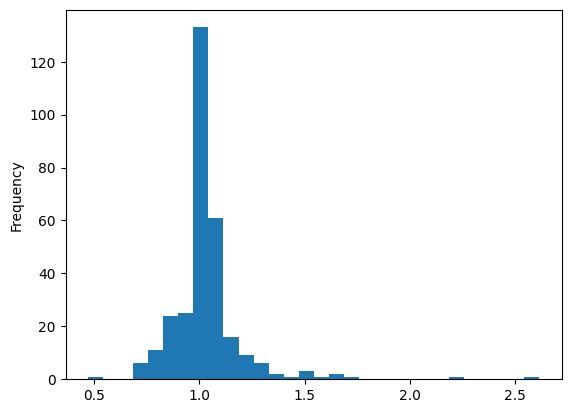

In [18]:
ratio.plot(kind='hist', bins=30)

In [19]:
#Summary Stats of each species
ratio.groupby(result['Species']).describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Acer pseudoplatanus,3.0,0.866615,0.016988,0.849488,0.858192,0.866897,0.875179,0.883461
Betula pendula,28.0,0.873164,0.153414,0.747190,0.807188,0.843360,0.864267,1.528802
Carpinus betulus,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fagus sylvatica,234.0,1.081061,0.173876,0.982209,1.001748,1.033593,1.078751,2.614178
Larix decidua,1.0,0.878462,NaN,0.878462,0.878462,0.878462,0.878462,0.878462
Picea Abies,6.0,0.687181,0.108165,0.472021,0.699175,0.732366,0.733543,0.764285
Pinus sylvestris,31.0,0.912248,0.014980,0.887102,0.902004,0.907292,0.921167,0.944219
Quercus robur,1.0,0.923948,NaN,0.923948,0.923948,0.923948,0.923948,0.923948


All values of *Carpinus betulus* tells us that there is no formula and parameters for this species in Zianis et al. (2005). The standard deviation for *Larix decidua* and *Quercus robur* is NaN because there is only one tree for each species.

## Step 5: Summary Statistics

Let's analyze the calculated volumes and compare them across species.

In [20]:
print(
    "Note: Volumes were computed for all species parameterized in Zianis et al. (2005); unsupported species were excluded from volume statistics.\n"
)
print("Overall SUMMARY Statistics")
valid_trees = result[result['Volume_Calculated'].notna()]
print(f"\nTotal number of trees analyzed: {len(valid_trees)}")
print(f"Number of different species: {valid_trees['Species'].nunique()}")

print("\nTree Measurements:")
print(f"Average diameter (DBH): {valid_trees['DBH_cm'].mean():.1f} cm")
print(f"Diameter range: {valid_trees['DBH_cm'].min():.1f} - {valid_trees['DBH_cm'].max():.1f} cm")

print(f"\nAverage height: {valid_trees['Height_m'].mean():.1f} m")
print(f"Height range: {valid_trees['Height_m'].min():.1f} - {valid_trees['Height_m'].max():.1f} m")

print("\nCalculated Volumes (using Zianis equations):")
print(f"Average volume: {valid_trees['Volume_Calculated'].mean():.3f} m³")
print(f"Volume range: {valid_trees['Volume_Calculated'].min():.3f} - {valid_trees['Volume_Calculated'].max():.3f} m³")
print(f"Total volume: {valid_trees['Volume_Calculated'].sum():.2f} m³")

Note: Volumes were computed for all species parameterized in Zianis et al. (2005); unsupported species were excluded from volume statistics.

Overall SUMMARY Statistics

Total number of trees analyzed: 304
Number of different species: 7

Tree Measurements:
Average diameter (DBH): 35.1 cm
Diameter range: 8.0 - 78.3 cm

Average height: 27.3 m
Height range: 3.7 - 37.7 m

Calculated Volumes (using Zianis equations):
Average volume: 1.557 m³
Volume range: 0.039 - 7.932 m³
Total volume: 473.32 m³


In [21]:
tree_data["h [m]"].min()

np.float64(3.7)

In [22]:
tree_data["h [m]"].max()

np.float64(37.7)

In [23]:
tree_data["d 1.3 [cm]"].min()

np.float64(8.0)

In [24]:
tree_data["d 1.3 [cm]"].max()

np.float64(78.3)

In [25]:
tree_data["TrSpec"].count()

np.int64(312)

In [26]:
print("Statistics by Species")

#Calculate statistics for each species
for species in sorted(result['Species'].unique()):
    species_data = result[result['Species'] == species]
    
    count = len(species_data)
    avg_dbh = species_data['DBH_cm'].mean()
    avg_height = species_data['Height_m'].mean()
    avg_volume = species_data['Volume_Calculated'].mean()
    total_volume = species_data['Volume_Calculated'].sum()
    print(f"\n{species}:")
    print(f"  Number of trees: {count}")
    print(f"  Average DBH: {avg_dbh:.1f} cm")
    print(f"  Average height: {avg_height:.1f} m")
    
    # Only print volume through this conditional

    valid_volumes = species_data['Volume_Calculated'].notna().sum()
    
    print(f"  Number of trees with volume: {valid_volumes}")
    
    if valid_volumes == 0:
        print("  Average volume: not computed")
        print("  Total volume: not computed")
    else:
        print(f"  Average volume: {avg_volume:.3f} m³")
        print(f"  Total volume: {total_volume:.2f} m³")

Statistics by Species

Acer pseudoplatanus:
  Number of trees: 3
  Average DBH: 49.0 cm
  Average height: 29.9 m
  Number of trees with volume: 3
  Average volume: 2.332 m³
  Total volume: 7.00 m³

Betula pendula:
  Number of trees: 28
  Average DBH: 42.3 cm
  Average height: 26.2 m
  Number of trees with volume: 28
  Average volume: 1.604 m³
  Total volume: 44.91 m³

Carpinus betulus:
  Number of trees: 8
  Average DBH: 19.9 cm
  Average height: 22.3 m
  Number of trees with volume: 0
  Average volume: not computed
  Total volume: not computed

Fagus sylvatica:
  Number of trees: 234
  Average DBH: 32.2 cm
  Average height: 26.8 m
  Number of trees with volume: 234
  Average volume: 1.396 m³
  Total volume: 326.57 m³

Larix decidua:
  Number of trees: 1
  Average DBH: 78.3 cm
  Average height: 36.7 m
  Number of trees with volume: 1
  Average volume: 7.296 m³
  Total volume: 7.30 m³

Picea Abies:
  Number of trees: 6
  Average DBH: 36.4 cm
  Average height: 26.6 m
  Number of trees wi

## Step 6: Validation - Error Analysis

To validate our implementation of the Zianis equationsm we compare our calculated volumes against the refernce volumes in the dataset.

### Error Metrics Explianed:

- **R-squared**: How well our calculations matche the reference (1.0 = perfect)
- **RMSE (Root Mean Square Error)**: Average size of errors in m³
- **Bias (Mean Error)**: Are we symmeterically over- or under-estimating?
- **MAE (Mean Absolute Error)**: Average error ignoring direction

In [27]:
# Only analyze the trees that have reference volumes
validation_data = result[result['Volume_Reference'].notna() & result['Volume_Calculated'].notna()].copy()

if len(validation_data) > 0:
    reference = validation_data['Volume_Reference'].values
    calculated = validation_data['Volume_Calculated'].values

    #Calculate Errors
    errors = calculated - reference
    
    #Error metrics
    correlation = np.corrcoef(reference, calculated)[0,1]
    r_squared = correlation ** 2
    
    rmse = np.sqrt(np.mean(errors**2))
    
    bias = np.mean(errors)
    
    mae = np.mean(np.abs(errors))
    
    mape = np.mean(np.abs(errors/reference)*100)
    
    #Print result
    
    print(f"Validation based on {len(validation_data)} trees")
    print(f"\nError Mertics:")
    print(f"R-squared (Coefficient of Determination): {r_squared:.4f}")
    print(f"Interpertation: {r_squared*100:.2f}% of variance explained")
    
    print(f"\nRMSE (Root Mean Square Error): {rmse:.4f} meter cubic")
    print(f"Interpertation: Typical error is \u00B1 {rmse:.3f} meter cubic")
    
    print(f"\nBIAS (Mean Error): {bias:.4f} m³")
    
    if abs(bias) < 0.01:
        print(f"Interpertation: Negligible bias (nearly unbiased)")
    elif bias > 0:
        print(f"Interpertation: Slight overestimation on average")
    else: 
        print(f"Interpertation: Slight underestimation on average")
    
    print(f"\nMAE (Mean Absolute Error): {mae:.4f} m³")
    print(f"Interpertation: Average error size is {mae:.3f} m³")
    
    print(f"\nMAPE (Mean Absolute % Error): {mape:.2f}%")
    print(f"Interpertation: Average error is {mape:.3f}% of tree volume")
    
    # Overall Assessment:
    if r_squared > 0.95 and abs(bias) < 0.2:
        print(f"Excellent: The Zianis equations work well for this dataset!")
    elif r_squared > 0.90 and abs(bias) < 0.01:
        print(f"Good: The Zianis equations provide reliable estimates with negligible bias.")
    elif r_squared > 0.95:
        print(f"Good: The Zianis equations provide reliable estimates.")
    else:
        print(f"Acceptable: Results are acceptable but could be improved.")
    print("="*30)
else:
    print("\n No reference volumes available for validation.")

Validation based on 304 trees

Error Mertics:
R-squared (Coefficient of Determination): 0.9317
Interpertation: 93.17% of variance explained

RMSE (Root Mean Square Error): 0.3412 meter cubic
Interpertation: Typical error is ± 0.341 meter cubic

BIAS (Mean Error): -0.0029 m³
Interpertation: Negligible bias (nearly unbiased)

MAE (Mean Absolute Error): 0.1659 m³
Interpertation: Average error size is 0.166 m³

MAPE (Mean Absolute % Error): 9.90%
Interpertation: Average error is 9.898% of tree volume
Good: The Zianis equations provide reliable estimates with negligible bias.


## Step 7: Visualizations

Now lets create graphs to visualize our results

### 7.1 Parity Plot - Calculated vs Reference volumes

This plot shows how well our calculated volumes match the reference volumes.
- Points on the red diagonal line = Perfect match
- Points above the red line = overestimation
- Points below the red line = underestimation

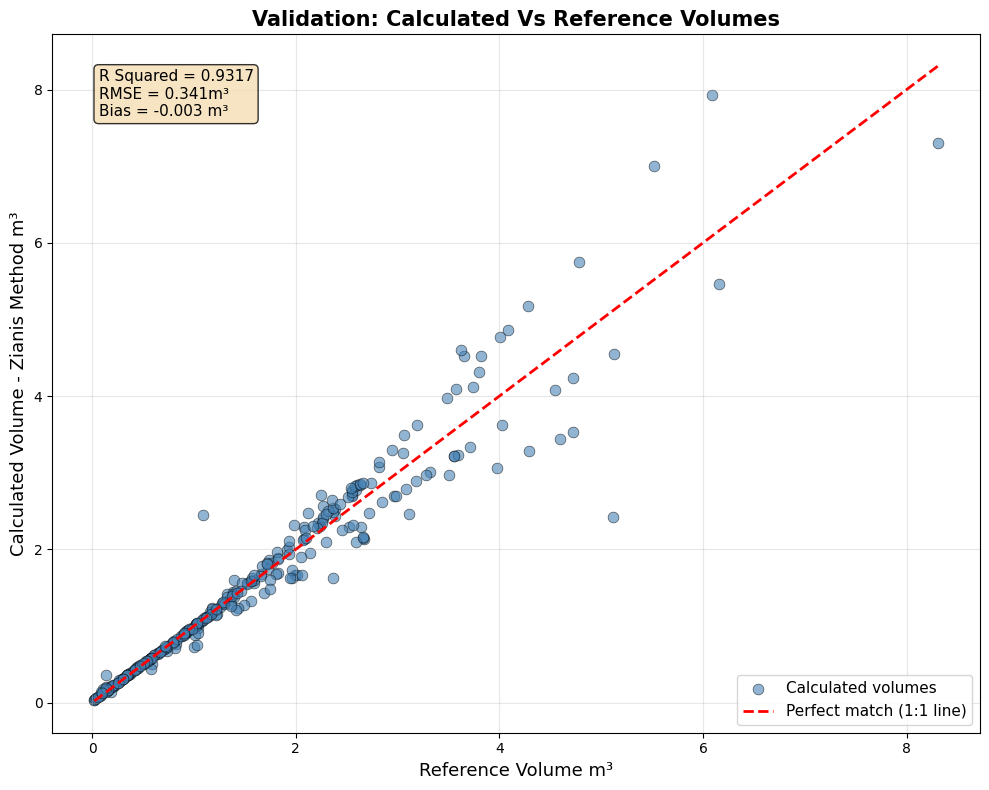

In [29]:
if len(validation_data)>0:
    validation_data = validation_data[validation_data['Volume_Calculated'].notna()]
    
    # Create plot
    plt.figure(figsize=(10,8))
    
    #Scatter Plot
    plt.scatter(validation_data['Volume_Reference'], 
                validation_data['Volume_Calculated'], 
                alpha = 0.6, s = 60, color = 'Steelblue', 
                edgecolors = 'black', linewidth = 0.5, 
                label = 'Calculated volumes')
    
    #ADD 1:1 perfect match line
    min_vol = min(validation_data['Volume_Reference'].min(), validation_data['Volume_Calculated'].min())
    max_vol = max(validation_data['Volume_Reference'].max(), validation_data['Volume_Calculated'].max())
    
    plt.plot([min_vol, max_vol], [min_vol, max_vol], 'r--', linewidth= 2, label = 'Perfect match (1:1 line)')
    
    #ADD Statistics box
    stats_text = f"R Squared = {r_squared:.4f}\nRMSE = {rmse:.3f}m³\nBias = {bias:+.3f} m³"
    plt.text(0.05, 0.95, stats_text,
            transform =plt.gca().transAxes,
            verticalalignment = 'top',
            bbox=dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.8),
            fontsize = 11)
    plt.xlabel('Reference Volume m³', fontsize = 13)
    plt.ylabel('Calculated Volume - Zianis Method m³', fontsize = 13)
    plt.title('Validation: Calculated Vs Reference Volumes', fontsize = 15, fontweight = 'bold')
    plt.legend(fontsize = 11)
    plt.grid(True, alpha = 0.3)
    plt.tight_layout()
    
    #Save the plot
    plt.savefig('Plots/Parity_plot.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

else:
    print("Cannot create the parity plot - no reference volumes available.")

### 7.2 Distribution Plot

These plots shows the distribution of the tree measurements and calculated volumes.

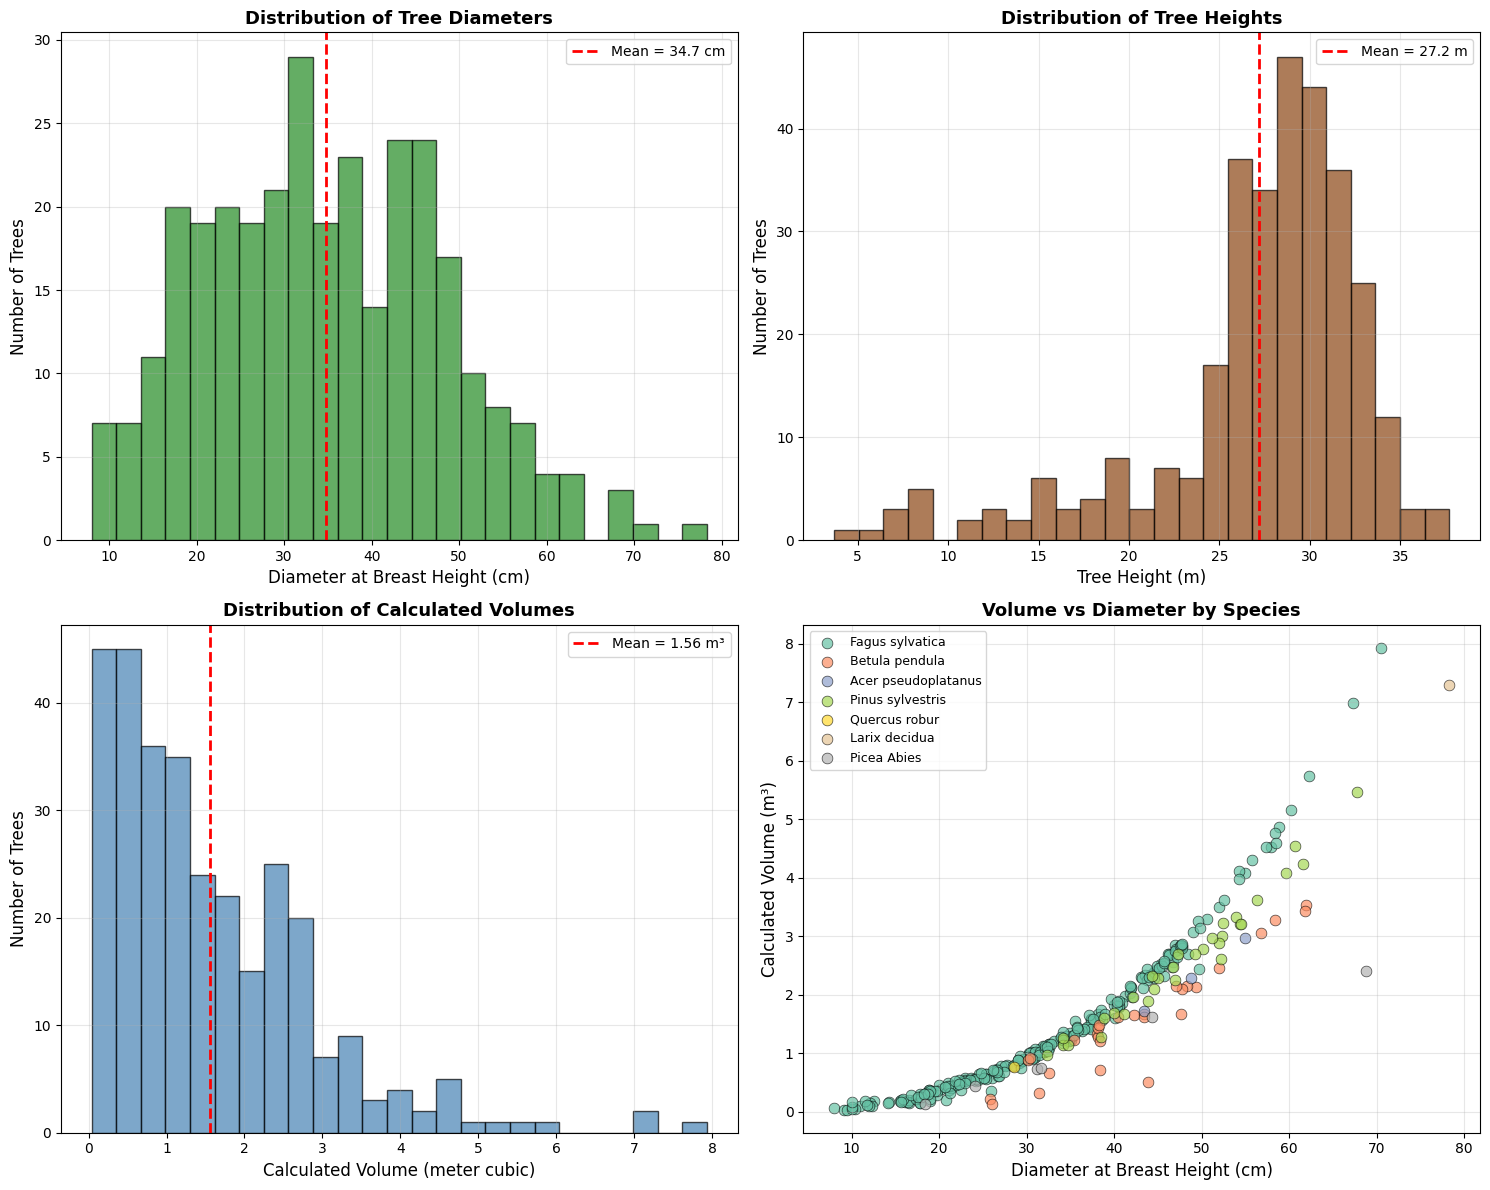

In [30]:
#Create Plot
fig, axes = plt.subplots(2, 2, figsize = (15, 12))

#Plot 1: DBH Distribution
axes[0, 0].hist(result['DBH_cm'], bins=25, color='forestgreen', 
               alpha=0.7, edgecolor='black')
axes[0, 0].axvline(result['DBH_cm'].mean(), color='red', 
                  linestyle='--', linewidth=2, label=f'Mean = {result["DBH_cm"].mean():.1f} cm')
axes[0, 0].set_xlabel('Diameter at Breast Height (cm)', fontsize=12)
axes[0, 0].set_ylabel('Number of Trees', fontsize=12)
axes[0, 0].set_title('Distribution of Tree Diameters', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

#Plot 2: Height Distribution
axes[0, 1].hist(result['Height_m'], bins=25, color='saddlebrown', 
               alpha=0.7, edgecolor='black')
axes[0, 1].axvline(result['Height_m'].mean(), color='red', 
                  linestyle='--', linewidth=2, label=f'Mean = {result["Height_m"].mean():.1f} m')
axes[0, 1].set_xlabel('Tree Height (m)', fontsize=12)
axes[0, 1].set_ylabel('Number of Trees', fontsize=12)
axes[0, 1].set_title('Distribution of Tree Heights', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
#Filter only trees with calculated volumes for volume-related plots
plot_data = result[result['Volume_Calculated'].notna()].copy()

#Plot 3: Volume Distribution
axes[1, 0].hist(plot_data['Volume_Calculated'], bins=25, color='steelblue', 
               alpha=0.7, edgecolor='black')
axes[1, 0].axvline(result['Volume_Calculated'].mean(), color='red', 
                  linestyle='--', linewidth=2, label=f'Mean = {result["Volume_Calculated"].mean():.2f} m³')
axes[1, 0].set_xlabel('Calculated Volume (meter cubic)', fontsize=12)
axes[1, 0].set_ylabel('Number of Trees', fontsize=12)
axes[1, 0].set_title('Distribution of Calculated Volumes', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

#Plot 4: DBH vs Volume scatter 
#Give species different color to easily understand the graph
species_list = plot_data['Species'].unique()
colors = plt.cm.Set2(np.linspace(0,1, len(species_list)))

for idx, species in enumerate(species_list):
    species_data = result[result['Species'] == species]
    axes[1, 1].scatter(species_data['DBH_cm'], species_data['Volume_Calculated'],
                      alpha=0.7, s=60, label=species, color=colors[idx],
                      edgecolors='black', linewidth=0.5)

axes[1, 1].set_xlabel('Diameter at Breast Height (cm)', fontsize=12)
axes[1, 1].set_ylabel('Calculated Volume (m³)', fontsize=12)
axes[1, 1].set_title('Volume vs Diameter by Species', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=9, loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Plots/distribution_plots.png', dpi=300, bbox_inches='tight')
plt.show()

### 7.3 Box Plot - Volume by Species

This shows the distribution of volumes for each species:
- Box plot show the middle 50% of the data (25% to 75% percentile)
- Line inside box = median
- Whiskers = range of data
- Dots = outliers

<Figure size 1000x1000 with 0 Axes>

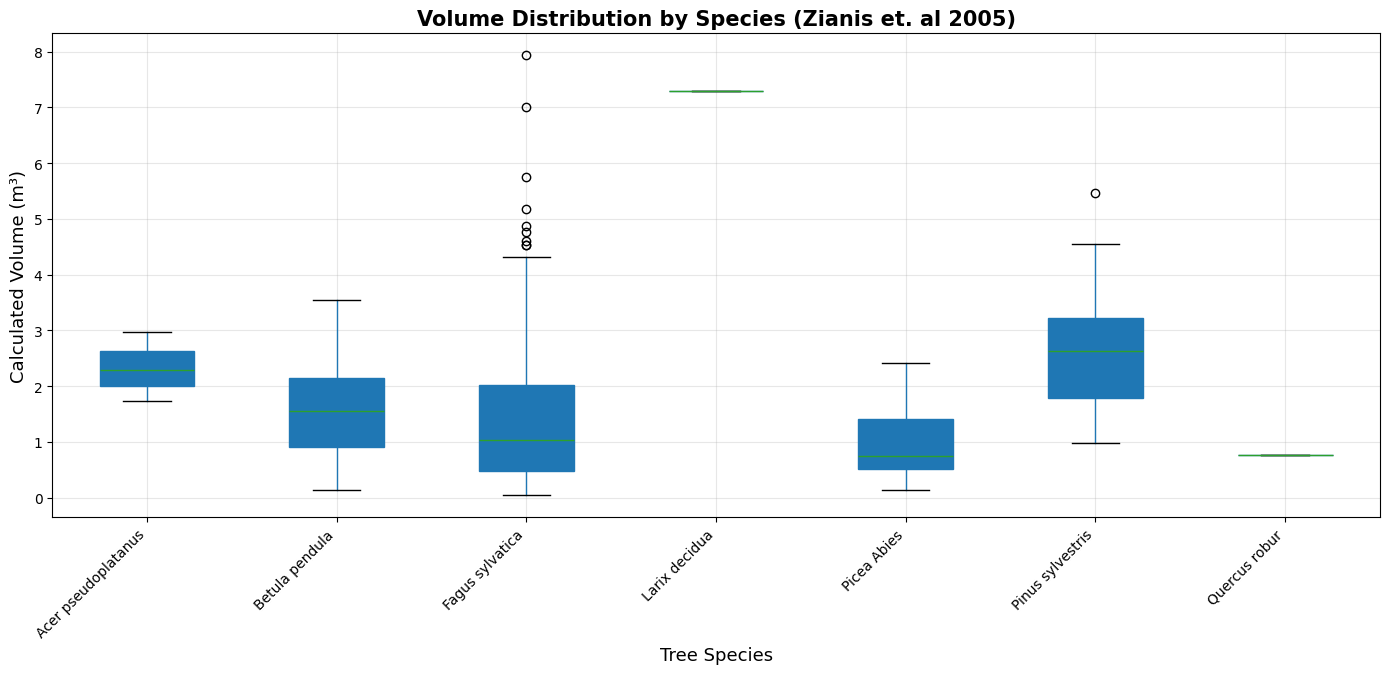

In [31]:
# Filter only trees with calculated volumes
plot_data = result[result['Volume_Calculated'].notna()].copy()

plt.figure(figsize=(10, 10))

#Create box plot
plot_data.boxplot(column='Volume_Calculated', by='Species', figsize=(14,7), patch_artist = True)

plt.xlabel('Tree Species', fontsize=13)
plt.ylabel('Calculated Volume (m³)', fontsize=13)
plt.title('Volume Distribution by Species (Zianis et. al 2005)', fontsize=15, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('Plots/boxplot_species.png', dpi=300, bbox_inches='tight')
plt.show()

### 7.4 Residual Plot - Error Analysis

This plot represents the difference between calculated and reference volumes.
- The red dashed line shows zero error (perfect prediction).
- The orange dotted lines show **±RMSE**, representing the typical error range (~68% of trees, ~1 standard deviation).
- **±2×RMSE** bands can be added to visualize the range covering ~95% of the expected error, ~2 standard deviation.

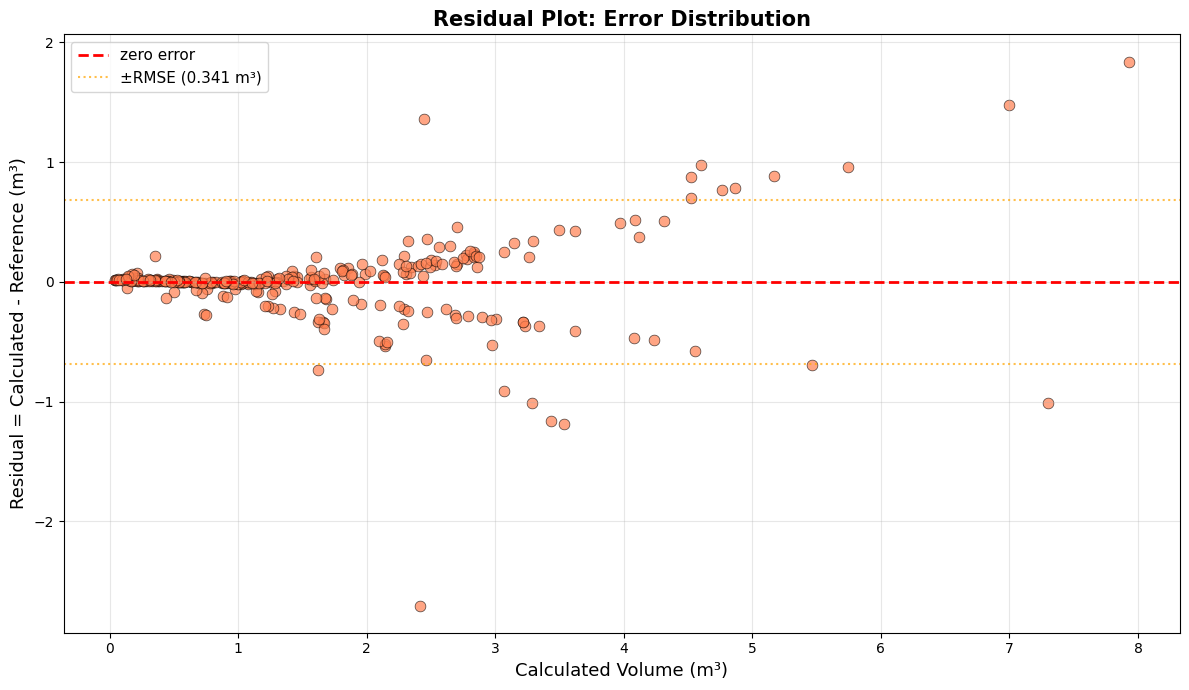

In [32]:
if len(validation_data) > 0:
    validation_data = validation_data.copy()
    validation_data['Residual']= validation_data['Volume_Calculated'] - validation_data['Volume_Reference']
    
    plt.figure(figsize=(12,7))
    
    #Scatter plot of residuals
    plt.scatter(validation_data['Volume_Calculated'],
               validation_data['Residual'],
               alpha = 0.7, s = 60, color = 'coral',
               edgecolors = 'black', linewidth= 0.5)
    
    #zero line (Perfect Prediction)
    plt.axhline(y = 0, color = 'red', linestyle = '--', linewidth = 2, label = 'zero error')
    
    # Add \u00B1 RMSE bands 
    plt.axhline(y=2*rmse, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=f'\u00B1RMSE ({rmse:.3f} m³)')
    plt.axhline(y=-2*rmse, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    
    plt.xlabel('Calculated Volume (m³)', fontsize=13)
    plt.ylabel('Residual = Calculated - Reference (m³)', fontsize=13)
    plt.title('Residual Plot: Error Distribution', fontsize=15, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.savefig('Plots/residual_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Cannot create residual plot - no reference volumes available.")

### Step 8: Save Results to CSV File

In [34]:
#Save the complete results
result.to_csv('Final_Result/HaselBurg_Volume_Results.csv', index = False)
print("Results saved Successfully!")

Results saved Successfully!


## Step 9: Conclusions

The analysis show us that species-specific allometric equations provide relaible estimates of stem volume, with minor and explainable devations. Median and mean ratios are close to one, errors are small, and the method succeefully captures species-specific growth patterns. This approach is scientifically sound, operationally practical, and provides a helpful in foundation for forest stand volume assessment.

## Files Created by this Analysis

Running this notebook creates the following files:
1. **haselberg_volume_results.csv** - Complete results data
2. **parity_plot.png** - Validation plot (calculated vs reference)
3. **distribution_plots.png** - Four distribution plots
4. **boxplot_species.png** - Volume distribution by species
5. **residual_plot.png** - Error distribution analysis

All files are saved in the same folder as this notebook.

## Reference

Zianis, D., Muukkonen, P., Mäkipää, R., & Mencuccini, M. (2005). *Biomass and stem volume equations for tree species in Europe*. Silva Fennica Monographs 4. 63 p.